## 1 - Install Packages

In [ ]:
# ============================================================
# Cell 1: Install packages (Colab-safe)
# ============================================================
!pip -q install --upgrade pip
!pip -q install "jax[cpu]" optax pandas matplotlib scikit-learn networkx torch torchvision torchaudio
!pip -q install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00


## 2 - imports and configs

In [ ]:
# ============================================================
# Cell 2: Imports, global config, and output folders
# ============================================================
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import torch
from torch_geometric.datasets import Twitch
from torch_geometric.utils import to_networkx

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

# -----------------------------
# Global experiment config
# -----------------------------
DATASET_NAMES = ["DE", "EN", "ES", "FR", "PT", "RU"]
SEEDS = [0, 1, 2, 3, 4]   # increase to 10 later if desired

MAIN_METRIC = "f1"
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

DEFAULT_CONFIG = {
    "hidden_dim": 16,          # hidden size per head
    "num_layers": 3,           # number of GAT layers
    "num_heads": 4,            # attention heads in hidden layers
    "dropout_rate": 0.5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 30,
    "batch_size": None,        # still full-batch over all nodes
    "add_self_loops": True
}

# Ablation grids
ABLATION_GRID = {
    "hidden_dim": [8, 16, 32],
    "num_layers": [2, 3, 4],
    "num_heads": [1, 2, 4, 8],
    "dropout_rate": [0.0, 0.2, 0.5]
}

# -----------------------------
# Paths
# -----------------------------
ROOT_OUTPUT_DIR = "outputs"
METRICS_DIR = os.path.join(ROOT_OUTPUT_DIR, "metrics")
FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT_OUTPUT_DIR, "models")
SPLITS_DIR = os.path.join(ROOT_OUTPUT_DIR, "splits")

for path in [ROOT_OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR]:
    os.makedirs(path, exist_ok=True)

# -----------------------------
# Numeric settings
# -----------------------------
JAX_DTYPE = jnp.float32
NP_DTYPE = np.float32

print("Output directory:", ROOT_OUTPUT_DIR)
print("Datasets:", DATASET_NAMES)
print("Seeds:", SEEDS)
print("Default config:", DEFAULT_CONFIG)

JAX version: 0.7.2
JAX devices: [CudaDevice(id=0)]
Output directory: outputs
Datasets: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Default config: {'hidden_dim': 16, 'num_layers': 3, 'num_heads': 4, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'max_epochs': 200, 'patience': 30, 'batch_size': None, 'add_self_loops': True}


## 3 - utilities

In [ ]:
# ============================================================
# Cell 3: Utility functions
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / exp_vals.sum(axis=1, keepdims=True)

def compute_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    probs = softmax_numpy(logits)
    y_pred = probs.argmax(axis=1)

    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["f1"] = float(f1_score(y_true, y_pred, average="binary"))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    # ROC-AUC only if both classes are present
    if len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, probs[:, 1]))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20
) -> Dict[str, np.ndarray]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    n = len(y)
    indices = np.arange(n)

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        stratify=y
    )

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx, _, _ = train_test_split(
        temp_idx,
        y_temp,
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        stratify=y_temp
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx)
    }

def make_mask(indices: np.ndarray, n: int) -> np.ndarray:
    mask = np.zeros(n, dtype=bool)
    mask[indices] = True
    return mask

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1

    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def add_self_loops_to_edge_index(edge_index: np.ndarray, num_nodes: int) -> np.ndarray:
    self_loops = np.arange(num_nodes, dtype=np.int64)
    self_loops = np.stack([self_loops, self_loops], axis=0)
    edge_index_out = np.concatenate([edge_index, self_loops], axis=1)

    # remove duplicates
    edge_tuples = edge_index_out.T
    edge_tuples = np.unique(edge_tuples, axis=0)
    return edge_tuples.T.astype(np.int64)

def build_incoming_edge_index(edge_index: np.ndarray) -> np.ndarray:
    # GAT aggregation will be over incoming neighbors to each destination node.
    # We keep shape (2, E): row 0 = src, row 1 = dst
    return edge_index.astype(np.int64)

def segment_softmax_numpy_style(scores: jnp.ndarray, dst: jnp.ndarray, num_nodes: int) -> jnp.ndarray:
    # scores: (E,)
    max_per_dst = jax.ops.segment_max(scores, dst, num_segments=num_nodes)
    stabilized = scores - max_per_dst[dst]
    exp_scores = jnp.exp(stabilized)
    denom = jax.ops.segment_sum(exp_scores, dst, num_segments=num_nodes)
    return exp_scores / (denom[dst] + 1e-12)

def plot_training_curves(history: Dict[str, List[float]], title: str, save_path: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_bar_with_error(
    df: pd.DataFrame,
    metric_col: str,
    std_col: str,
    title: str,
    save_path: str
) -> None:
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    plt.bar(x, df[metric_col].values, yerr=df[std_col].values, capsize=5)
    plt.xticks(x, df["dataset"].values)
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

## 4 - load twitch

In [ ]:
# ============================================================
# Cell 4 (REPLACEMENT v2): Download Twitch MUSAE files directly
# ============================================================
import os
import json
import urllib.request
import urllib.error

RAW_TWITCH_DIR = "data/twitch_manual_direct"
os.makedirs(RAW_TWITCH_DIR, exist_ok=True)

# Notebook names -> raw domain names used by public MUSAE mirrors
DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

# Public raw file mirror
BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading {url}")
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(f"Failed to download {url}\nOriginal error: {repr(e)}")

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1
    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def load_direct_domain(domain_code: str):
    domain_dir = os.path.join(RAW_TWITCH_DIR, domain_code)
    os.makedirs(domain_dir, exist_ok=True)

    edges_path = os.path.join(domain_dir, f"musae_{domain_code}_edges.csv")
    features_path = os.path.join(domain_dir, f"musae_{domain_code}_features.json")
    target_path = os.path.join(domain_dir, f"musae_{domain_code}_target.csv")

    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_edges.csv",
        edges_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_features.json",
        features_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_target.csv",
        target_path
    )

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    required_cols = {"id", "new_id", "mature"}
    missing = required_cols - set(target_df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns {missing} in {target_path}. "
            f"Found columns: {list(target_df.columns)}"
        )

    # Sort by new_id so feature rows line up with JSON keys
    target_df = target_df.sort_values("new_id").reset_index(drop=True)

    original_ids = target_df["id"].astype(int).tolist()
    new_ids = target_df["new_id"].astype(int).tolist()

    original_id_to_row = {oid: i for i, oid in enumerate(original_ids)}
    new_id_to_row = {nid: i for i, nid in enumerate(new_ids)}

    num_nodes = len(target_df)

    # -----------------------------
    # Features keyed by new_id
    # -----------------------------
    feature_keys_int = set(int(k) for k in features_dict.keys())
    if not set(new_ids).issubset(feature_keys_int):
        raise ValueError(
            f"Feature JSON keys do not cover all new_id values for domain {domain_code}."
        )

    max_feat_index = -1
    for nid in new_ids:
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            max_feat_index = max(max_feat_index, max(feat_list))

    num_features = max_feat_index + 1
    x_np = np.zeros((num_nodes, num_features), dtype=np.float32)

    for row_idx, nid in enumerate(new_ids):
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            x_np[row_idx, np.asarray(feat_list, dtype=np.int64)] = 1.0

    # -----------------------------
    # Labels
    # -----------------------------
    y_np = target_df["mature"].astype(int).to_numpy(dtype=np.int64)

    # -----------------------------
    # Edges
    # Try both original-id indexing and new_id indexing.
    # -----------------------------
    edge_cols_lower = {c.lower(): c for c in edges_df.columns}
    if "from" in edge_cols_lower and "to" in edge_cols_lower:
        src_col = edge_cols_lower["from"]
        dst_col = edge_cols_lower["to"]
    else:
        if edges_df.shape[1] < 2:
            raise ValueError(f"Edge file {edges_path} has fewer than 2 columns.")
        src_col = edges_df.columns[0]
        dst_col = edges_df.columns[1]

    src_raw = edges_df[src_col].astype(int).to_numpy()
    dst_raw = edges_df[dst_col].astype(int).to_numpy()

    def build_edges(id_to_row):
        edge_pairs = []
        missing_count = 0
        for s, t in zip(src_raw, dst_raw):
            if s in id_to_row and t in id_to_row:
                edge_pairs.append((id_to_row[s], id_to_row[t]))
            else:
                missing_count += 1
        return edge_pairs, missing_count

    # First try original Twitch ids
    edge_pairs_orig, missing_orig = build_edges(original_id_to_row)

    # Then try new_id indexing
    edge_pairs_new, missing_new = build_edges(new_id_to_row)

    if len(edge_pairs_orig) > 0:
        edge_pairs = edge_pairs_orig
        missing_count = missing_orig
        edge_id_mode = "original_id"
    elif len(edge_pairs_new) > 0:
        edge_pairs = edge_pairs_new
        missing_count = missing_new
        edge_id_mode = "new_id"
    else:
        raise ValueError(
            f"No valid edges remained after trying both original id and new_id alignment "
            f"for domain {domain_code}."
        )

    edge_index_np = np.asarray(edge_pairs, dtype=np.int64).T

    # Remove self-loops if any
    keep = edge_index_np[0] != edge_index_np[1]
    edge_index_np = edge_index_np[:, keep]

    # Undirected summary
    edge_pairs_sorted = np.sort(edge_index_np.T, axis=1)
    unique_undirected_edges = np.unique(edge_pairs_sorted, axis=0)
    num_edges_undirected = int(unique_undirected_edges.shape[0])

    row = {
        "num_nodes": num_nodes,
        "num_edges_directed_count": int(edge_index_np.shape[1]),
        "num_edges_undirected_approx": num_edges_undirected,
        "num_features": int(x_np.shape[1]),
        "class_0_count": int((y_np == 0).sum()),
        "class_1_count": int((y_np == 1).sum()),
        "class_1_fraction": float((y_np == 1).mean()),
        "feature_mean": float(x_np.mean()),
        "feature_std": float(x_np.std()),
        "density_undirected_approx": graph_density_undirected(num_nodes, num_edges_undirected),
        "dropped_edges_due_to_id_mismatch": int(missing_count),
        "edge_id_mode": edge_id_mode,
        **degree_stats_from_edge_index(edge_index_np, num_nodes),
    }

    return x_np, y_np, edge_index_np, row

dataset_objects = {}
dataset_data = {}
dataset_summary_rows = []

for name in DATASET_NAMES:
    raw_code = DOMAIN_MAP[name]
    print(f"Loading Twitch dataset: notebook={name}, raw_domain={raw_code}")

    x_np, y_np, edge_index_np, row = load_direct_domain(raw_code)
    row["dataset"] = name

    edge_index_for_gat = add_self_loops_to_edge_index(edge_index_np, x_np.shape[0])

    dataset_objects[name] = None
    dataset_data[name] = {
        "data_obj": None,
        "x_np": x_np,
        "y_np": y_np,
        "edge_index_np": edge_index_np,
        "edge_index_gat_np": edge_index_for_gat
    }
    dataset_summary_rows.append(row)

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
display(dataset_summary_df)

dataset_summary_path = os.path.join(METRICS_DIR, "gat_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)

print(f"Saved dataset summary to: {dataset_summary_path}")

Loading Twitch dataset: notebook=DE, raw_domain=DE
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
Loading Twitch dataset: notebook=ES, raw_domain=ES
Loading Twitch dataset: notebook=FR, raw_domain=FR
Loading Twitch dataset: notebook=PT, raw_domain=PTBR
Loading Twitch dataset: notebook=RU, raw_domain=RU


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR
4,1912,31299,31299,3169,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU


Saved dataset summary to: outputs/metrics/gat_dataset_summary.csv


## 4B

In [ ]:
# ============================================================
# Cell 4B: Make feature dimensions compatible for cross-graph transfer
# ============================================================
# Transfer requires that a model trained on one Twitch graph can be evaluated
# on another Twitch graph. Therefore all feature matrices must have the same
# number of columns.

original_feature_dims = {
    name: int(dataset_data[name]["x_np"].shape[1])
    for name in DATASET_NAMES
}

GLOBAL_FEATURE_DIM = max(original_feature_dims.values())

print("Original feature dimensions:", original_feature_dims)
print("Global padded feature dimension:", GLOBAL_FEATURE_DIM)

def pad_features_to_global_dim(x_np: np.ndarray, global_dim: int) -> np.ndarray:
    current_dim = x_np.shape[1]
    if current_dim == global_dim:
        return x_np.astype(np.float32)

    if current_dim > global_dim:
        raise ValueError(
            f"Current feature dim {current_dim} is larger than global dim {global_dim}."
        )

    pad_width = global_dim - current_dim
    padding = np.zeros((x_np.shape[0], pad_width), dtype=np.float32)
    return np.concatenate([x_np.astype(np.float32), padding], axis=1)

for name in DATASET_NAMES:
    x_old = dataset_data[name]["x_np"]
    dataset_data[name]["x_np"] = pad_features_to_global_dim(x_old, GLOBAL_FEATURE_DIM)

# Update and re-save dataset summary with original and padded dimensions.
dataset_summary_df["original_num_features"] = dataset_summary_df["dataset"].map(original_feature_dims)
dataset_summary_df["padded_num_features"] = GLOBAL_FEATURE_DIM
dataset_summary_df["num_features"] = GLOBAL_FEATURE_DIM

dataset_summary_path = os.path.join(METRICS_DIR, "gat_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)

display(dataset_summary_df)

print(f"Updated dataset summary with padded feature dimensions.")
print(f"Saved updated dataset summary to: {dataset_summary_path}")

# Sanity check
for name in DATASET_NAMES:
    assert dataset_data[name]["x_np"].shape[1] == GLOBAL_FEATURE_DIM

print("All feature matrices now have compatible dimensions.")

Original feature dimensions: {'DE': 3170, 'EN': 3170, 'ES': 3170, 'FR': 3170, 'PT': 3169, 'RU': 3170}
Global padded feature dimension: 3170


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset,original_num_features,padded_num_features
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE,3170,3170
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN,3170,3170
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES,3170,3170
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR,3170,3170
4,1912,31299,31299,3170,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT,3169,3170
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU,3170,3170


Updated dataset summary with padded feature dimensions.
Saved updated dataset summary to: outputs/metrics/gat_dataset_summary.csv
All feature matrices now have compatible dimensions.


## 5 - dataset and splits

In [ ]:
# ============================================================
# Cell 5: Train/val/test splits
# ============================================================
all_splits = {}
split_rows = []

for name in DATASET_NAMES:
    y_np = dataset_data[name]["y_np"]
    n = len(y_np)
    all_splits[name] = {}

    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO
        )
        all_splits[name][seed] = splits

        split_rows.append({
            "dataset": name,
            "seed": seed,
            "n_total": n,
            "n_train": len(splits["train"]),
            "n_val": len(splits["val"]),
            "n_test": len(splits["test"]),
            "train_pos_frac": float(y_np[splits["train"]].mean()),
            "val_pos_frac": float(y_np[splits["val"]].mean()),
            "test_pos_frac": float(y_np[splits["test"]].mean())
        })

        save_json(
            {k: v.tolist() for k, v in splits.items()},
            os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        )

splits_df = pd.DataFrame(split_rows).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(splits_df.head(12))

splits_df.to_csv(os.path.join(METRICS_DIR, "gat_split_summary.csv"), index=False)
print("Saved split metadata.")

,dataset,seed,n_total,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac
0,DE,0,9498,5698,1900,1900,0.604598,0.604737,0.604211
1,DE,1,9498,5698,1900,1900,0.604598,0.604211,0.604737
2,DE,2,9498,5698,1900,1900,0.604598,0.604737,0.604211
3,DE,3,9498,5698,1900,1900,0.604598,0.604737,0.604211
4,DE,4,9498,5698,1900,1900,0.604598,0.604737,0.604211
5,EN,0,7126,4275,1425,1426,0.545497,0.545965,0.545582
6,EN,1,7126,4275,1425,1426,0.545497,0.545965,0.545582
7,EN,2,7126,4275,1425,1426,0.545497,0.545965,0.545582
8,EN,3,7126,4275,1425,1426,0.545497,0.545965,0.545582
9,EN,4,7126,4275,1425,1426,0.545497,0.545965,0.545582


Saved split metadata.


## 6 - GAT model

In [ ]:
# ============================================================
# Cell 6: GAT model definition (class-based, JAX ops)
# ============================================================
class GAT:
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 2,
        num_heads: int = 4,
        dropout_rate: float = 0.5
    ):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate

    def init_params(self, rng_key: jax.Array) -> Dict:
        params = {"layers": []}

        dims = [self.input_dim]
        for _ in range(self.num_layers - 1):
            dims.append(self.hidden_dim * self.num_heads)
        dims.append(self.output_dim)

        n_param_groups = self.num_layers
        keys = jax.random.split(rng_key, 4 * n_param_groups)

        key_ptr = 0
        for layer_idx in range(self.num_layers):
            in_dim = dims[layer_idx]

            if layer_idx < self.num_layers - 1:
                heads = self.num_heads
                out_dim_per_head = self.hidden_dim
            else:
                heads = 1
                out_dim_per_head = self.output_dim

            w_key = keys[key_ptr]
            a_src_key = keys[key_ptr + 1]
            a_dst_key = keys[key_ptr + 2]
            key_ptr += 4

            limit = math.sqrt(6.0 / (in_dim + heads * out_dim_per_head))
            W = jax.random.uniform(
                w_key,
                shape=(in_dim, heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )

            a_src = jax.random.uniform(
                a_src_key,
                shape=(heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )
            a_dst = jax.random.uniform(
                a_dst_key,
                shape=(heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )

            b = jnp.zeros((heads, out_dim_per_head), dtype=JAX_DTYPE)

            params["layers"].append({
                "W": W,
                "a_src": a_src,
                "a_dst": a_dst,
                "b": b
            })

        return params

    def _dropout(self, x: jnp.ndarray, rng_key: Optional[jax.Array], train: bool) -> jnp.ndarray:
        if (not train) or (self.dropout_rate <= 0.0) or (rng_key is None):
            return x
        keep_prob = 1.0 - self.dropout_rate
        mask = jax.random.bernoulli(rng_key, p=keep_prob, shape=x.shape)
        return jnp.where(mask, x / keep_prob, 0.0)

    def _gat_layer(
        self,
        layer_params: Dict,
        x: jnp.ndarray,
        edge_index: jnp.ndarray,
        num_nodes: int,
        rng_key: Optional[jax.Array],
        train: bool,
        concat: bool
    ) -> jnp.ndarray:
        # x: (N, Fin)
        # W: (Fin, H, Fout)
        W = layer_params["W"]
        a_src = layer_params["a_src"]
        a_dst = layer_params["a_dst"]
        b = layer_params["b"]

        src = edge_index[0]
        dst = edge_index[1]

        # linear projection
        h = jnp.einsum("nf,fho->nho", x, W) + b[None, :, :]   # (N, H, Fout)

        # source / target node projected embeddings on edges
        h_src = h[src]    # (E, H, Fout)
        h_dst = h[dst]    # (E, H, Fout)

        # additive attention score
        e_src = jnp.sum(h_src * a_src[None, :, :], axis=-1)   # (E, H)
        e_dst = jnp.sum(h_dst * a_dst[None, :, :], axis=-1)   # (E, H)
        e = jax.nn.leaky_relu(e_src + e_dst, negative_slope=0.2)  # (E, H)

        # edge dropout on attention logits if training
        if train and rng_key is not None and self.dropout_rate > 0.0:
            e = self._dropout(e, rng_key, train=True)

        # softmax over incoming edges per destination node, separately for each head
        def normalize_one_head(e_head):
            return segment_softmax_numpy_style(e_head, dst, num_nodes)

        alpha = jax.vmap(normalize_one_head, in_axes=1, out_axes=1)(e)   # (E, H)

        # weighted sum of source messages into dst
        messages = h_src * alpha[:, :, None]   # (E, H, Fout)

        def aggregate_one_head(msg_head):
            return jax.ops.segment_sum(msg_head, dst, num_segments=num_nodes)

        out = jax.vmap(aggregate_one_head, in_axes=1, out_axes=1)(messages)  # (N, H, Fout)

        if concat:
            out = out.reshape(num_nodes, -1)   # (N, H*Fout)
        else:
            out = out.mean(axis=1)             # (N, Fout)

        return out

    def __call__(
        self,
        params: Dict,
        x: jnp.ndarray,
        edge_index: jnp.ndarray,
        rng_key: Optional[jax.Array] = None,
        train: bool = False
    ) -> jnp.ndarray:
        h = x
        n_layers = len(params["layers"])

        layer_keys = None
        if rng_key is not None:
            layer_keys = jax.random.split(rng_key, n_layers)

        for i, layer in enumerate(params["layers"]):
            is_last = (i == n_layers - 1)
            h = self._gat_layer(
                layer_params=layer,
                x=h,
                edge_index=edge_index,
                num_nodes=h.shape[0],
                rng_key=None if layer_keys is None else layer_keys[i],
                train=train,
                concat=(not is_last)
            )

            if not is_last:
                h = jax.nn.elu(h)

        return h

print("GAT class defined.")

GAT class defined.


## 7 - training and eval functions

In [ ]:
# ============================================================
# Cell 7: Training and evaluation functions
# ============================================================
@dataclass
class TrainState:
    params: Dict
    opt_state: optax.OptState
    best_params: Dict
    best_val_metric: float
    best_epoch: int
    history: Dict[str, List[float]]

def cross_entropy_loss(logits: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    y_onehot = jax.nn.one_hot(y, num_classes=logits.shape[1])
    log_probs = jax.nn.log_softmax(logits, axis=1)
    return -jnp.mean(jnp.sum(y_onehot * log_probs, axis=1))

def l2_weight_penalty(params: Dict) -> jnp.ndarray:
    penalty = 0.0
    for layer in params["layers"]:
        penalty = penalty + jnp.sum(layer["W"] ** 2)
        penalty = penalty + jnp.sum(layer["a_src"] ** 2)
        penalty = penalty + jnp.sum(layer["a_dst"] ** 2)
    return penalty

def build_optimizer(learning_rate: float, weight_decay: float):
    # Decoupled weight decay
    return optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay)

def evaluate_split(
    model: GAT,
    params: Dict,
    x_jnp: jnp.ndarray,
    edge_index_jnp: jnp.ndarray,
    y_np: np.ndarray,
    split_idx: np.ndarray
) -> Tuple[float, Dict[str, float], np.ndarray]:
    logits = model(params, x_jnp, edge_index_jnp, rng_key=None, train=False)
    logits_np = np.asarray(logits)
    split_logits = logits_np[split_idx]
    split_y = y_np[split_idx]

    loss_val = float(cross_entropy_loss(jnp.asarray(split_logits), jnp.asarray(split_y)))
    metrics = compute_metrics(split_y, split_logits)
    return loss_val, metrics, split_logits

def train_one_run(
    x_np: np.ndarray,
    y_np: np.ndarray,
    edge_index_np: np.ndarray,
    splits: Dict[str, np.ndarray],
    seed: int,
    config: Dict,
    dataset_name: str,
    run_name: str,
    save_training_curve: bool = True
) -> Dict:
    set_global_seed(seed)

    x_jnp = jnp.asarray(x_np, dtype=JAX_DTYPE)
    y_jnp = jnp.asarray(y_np, dtype=jnp.int32)
    edge_index_jnp = jnp.asarray(edge_index_np, dtype=jnp.int32)

    train_idx = splits["train"]
    val_idx = splits["val"]
    test_idx = splits["test"]

    input_dim = x_np.shape[1]
    output_dim = len(np.unique(y_np))

    model = GAT(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        output_dim=output_dim,
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        dropout_rate=config["dropout_rate"]
    )

    init_key = jax.random.PRNGKey(seed)
    params = model.init_params(init_key)

    optimizer = build_optimizer(
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    opt_state = optimizer.init(params)

    @jax.jit
    def train_step(params, opt_state, step_key):
        def loss_fn(p):
            logits = model(p, x_jnp, edge_index_jnp, rng_key=step_key, train=True)
            train_logits = logits[train_idx]
            train_y = y_jnp[train_idx]
            data_loss = cross_entropy_loss(train_logits, train_y)
            return data_loss

        loss_value, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss_value

    state = TrainState(
        params=params,
        opt_state=opt_state,
        best_params=copy.deepcopy(params),
        best_val_metric=-np.inf,
        best_epoch=-1,
        history={
            "train_loss": [],
            "val_loss": [],
            "train_f1": [],
            "val_f1": []
        }
    )

    patience_counter = 0
    t0 = time.time()

    for epoch in range(config["max_epochs"]):
        step_key = jax.random.PRNGKey(seed * 10000 + epoch)
        state.params, state.opt_state, train_loss_jnp = train_step(state.params, state.opt_state, step_key)

        train_loss, train_metrics, _ = evaluate_split(model, state.params, x_jnp, edge_index_jnp, y_np, train_idx)
        val_loss, val_metrics, _ = evaluate_split(model, state.params, x_jnp, edge_index_jnp, y_np, val_idx)

        state.history["train_loss"].append(train_loss)
        state.history["val_loss"].append(val_loss)
        state.history["train_f1"].append(train_metrics["f1"])
        state.history["val_f1"].append(val_metrics["f1"])

        current_val_metric = val_metrics[MAIN_METRIC]

        if current_val_metric > state.best_val_metric:
            state.best_val_metric = current_val_metric
            state.best_epoch = epoch
            state.best_params = copy.deepcopy(state.params)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    elapsed = time.time() - t0

    # Final evaluation with best params
    best_params = state.best_params

    train_loss, train_metrics, train_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, train_idx)
    val_loss, val_metrics, val_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, val_idx)
    test_loss, test_metrics, test_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, test_idx)

    result = {
        "dataset": dataset_name,
        "seed": seed,
        "run_name": run_name,
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "num_heads": config["num_heads"],
        "dropout_rate": config["dropout_rate"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_epochs": config["max_epochs"],
        "patience": config["patience"],
        "best_epoch": state.best_epoch,
        "elapsed_seconds": elapsed,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "history": state.history,
        "best_params": best_params
    }

    if save_training_curve:
        curve_path = os.path.join(
            FIGURES_DIR,
            f"{dataset_name}_{run_name}_seed{seed}_training_curve.png"
        )
        plot_training_curves(
            state.history,
            title=f"{dataset_name} | {run_name} | seed={seed}",
            save_path=curve_path
        )

    return result

print("Training utilities ready.")

Training utilities ready.


## 10B

In [ ]:
# ============================================================
# Cell 10B: Cross-graph transfer helper functions
# ============================================================

TRANSFER_DIR = os.path.join(ROOT_OUTPUT_DIR, "transfer")
TRANSFER_METRICS_DIR = os.path.join(TRANSFER_DIR, "metrics")
TRANSFER_FIGURES_DIR = os.path.join(TRANSFER_DIR, "figures")

for path in [TRANSFER_DIR, TRANSFER_METRICS_DIR, TRANSFER_FIGURES_DIR]:
    os.makedirs(path, exist_ok=True)

def build_gat_model_from_config(
    input_dim: int,
    output_dim: int,
    config: Dict
) -> GAT:
    return GAT(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        output_dim=output_dim,
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        dropout_rate=config["dropout_rate"]
    )

def evaluate_transfer_target(
    params: Dict,
    config: Dict,
    target_x_np: np.ndarray,
    target_y_np: np.ndarray,
    target_edge_index_np: np.ndarray,
    target_split_idx: np.ndarray
) -> Tuple[float, Dict[str, float], np.ndarray]:
    """
    Evaluate source-trained GAT parameters on a target graph.

    The source and target graphs must have the same feature dimension and
    the same number of output classes.
    """
    input_dim = target_x_np.shape[1]
    output_dim = len(np.unique(target_y_np))

    model = build_gat_model_from_config(
        input_dim=input_dim,
        output_dim=output_dim,
        config=config
    )

    x_jnp = jnp.asarray(target_x_np, dtype=JAX_DTYPE)
    edge_index_jnp = jnp.asarray(target_edge_index_np, dtype=jnp.int32)

    logits = model(
        params,
        x_jnp,
        edge_index_jnp,
        rng_key=None,
        train=False
    )

    logits_np = np.asarray(logits)
    split_logits = logits_np[target_split_idx]
    split_y = target_y_np[target_split_idx]

    loss_val = float(
        cross_entropy_loss(
            jnp.asarray(split_logits),
            jnp.asarray(split_y)
        )
    )

    metrics = compute_metrics(split_y, split_logits)

    return loss_val, metrics, split_logits

def make_transfer_heatmap(
    matrix_df: pd.DataFrame,
    title: str,
    save_path: str,
    fmt: str = ".3f",
    cmap: str = "viridis"
) -> None:
    values = matrix_df.loc[DATASET_NAMES, DATASET_NAMES].values.astype(float)

    plt.figure(figsize=(7.5, 6))
    im = plt.imshow(values, cmap=cmap)

    plt.xticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
    plt.yticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
    plt.xlabel("Target / test graph")
    plt.ylabel("Source / train graph")
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                plt.text(
                    j,
                    i,
                    format(val, fmt),
                    ha="center",
                    va="center",
                    fontsize=9
                )

    plt.tight_layout()
    plt.savefig(save_path, dpi=250)
    plt.show()

print("Transfer helper functions ready.")
print("Transfer outputs will be saved under:", TRANSFER_DIR)

Transfer helper functions ready.
Transfer outputs will be saved under: outputs/transfer


## 10C

In [ ]:
# ============================================================
# Cell 10C: Run cross-graph transfer experiment for GAT
# ============================================================
# For each source graph S and each seed:
#   1. Train GAT on S using S's train/val split.
#   2. Evaluate the trained model on every target graph T using T's test split.
#
# This produces a 6 x 6 transfer matrix for each seed.

RUN_GAT_TRANSFER = True

transfer_results = []

if RUN_GAT_TRANSFER:
    for source_dataset in DATASET_NAMES:
        source_x_np = dataset_data[source_dataset]["x_np"]
        source_y_np = dataset_data[source_dataset]["y_np"]
        source_edge_index_np = dataset_data[source_dataset]["edge_index_gat_np"]

        print("=" * 90)
        print(f"Training source GAT models for transfer: source={source_dataset}")

        for seed in SEEDS:
            print(f"  Source={source_dataset}, seed={seed}: training source model")

            source_splits = all_splits[source_dataset][seed]

            source_result = train_one_run(
                x_np=source_x_np,
                y_np=source_y_np,
                edge_index_np=source_edge_index_np,
                splits=source_splits,
                seed=seed,
                config=DEFAULT_CONFIG,
                dataset_name=source_dataset,
                run_name=f"transfer_source_{source_dataset}",
                save_training_curve=False
            )

            source_best_params = source_result["best_params"]
            source_best_epoch = source_result["best_epoch"]

            source_num_classes = len(np.unique(source_y_np))

            for target_dataset in DATASET_NAMES:
                target_x_np = dataset_data[target_dataset]["x_np"]
                target_y_np = dataset_data[target_dataset]["y_np"]
                target_edge_index_np = dataset_data[target_dataset]["edge_index_gat_np"]

                target_num_classes = len(np.unique(target_y_np))
                if source_num_classes != target_num_classes:
                    raise ValueError(
                        f"Source {source_dataset} has {source_num_classes} classes, "
                        f"but target {target_dataset} has {target_num_classes} classes."
                    )

                if source_x_np.shape[1] != target_x_np.shape[1]:
                    raise ValueError(
                        f"Feature dimension mismatch: source {source_dataset} has "
                        f"{source_x_np.shape[1]} features, target {target_dataset} has "
                        f"{target_x_np.shape[1]} features. Make sure Cell 4B was run."
                    )

                target_splits = all_splits[target_dataset][seed]
                target_test_idx = target_splits["test"]

                transfer_loss, transfer_metrics, _ = evaluate_transfer_target(
                    params=source_best_params,
                    config=DEFAULT_CONFIG,
                    target_x_np=target_x_np,
                    target_y_np=target_y_np,
                    target_edge_index_np=target_edge_index_np,
                    target_split_idx=target_test_idx
                )

                row = {
                    "source_dataset": source_dataset,
                    "target_dataset": target_dataset,
                    "seed": seed,
                    "is_within_graph": bool(source_dataset == target_dataset),

                    "source_num_nodes": int(source_x_np.shape[0]),
                    "target_num_nodes": int(target_x_np.shape[0]),
                    "source_num_features": int(source_x_np.shape[1]),
                    "target_num_features": int(target_x_np.shape[1]),
                    "source_pos_frac": float(source_y_np.mean()),
                    "target_pos_frac": float(target_y_np.mean()),

                    "hidden_dim": DEFAULT_CONFIG["hidden_dim"],
                    "num_layers": DEFAULT_CONFIG["num_layers"],
                    "num_heads": DEFAULT_CONFIG["num_heads"],
                    "dropout_rate": DEFAULT_CONFIG["dropout_rate"],
                    "learning_rate": DEFAULT_CONFIG["learning_rate"],
                    "weight_decay": DEFAULT_CONFIG["weight_decay"],
                    "best_epoch_source": int(source_best_epoch),

                    "transfer_loss": float(transfer_loss),
                    "transfer_accuracy": float(transfer_metrics["accuracy"]),
                    "transfer_f1": float(transfer_metrics["f1"]),
                    "transfer_macro_f1": float(transfer_metrics["macro_f1"]),
                    "transfer_roc_auc": float(transfer_metrics["roc_auc"]),
                }

                transfer_results.append(row)

                print(
                    f"    eval source={source_dataset} -> target={target_dataset} | "
                    f"seed={seed} | F1={row['transfer_f1']:.4f} | "
                    f"macro-F1={row['transfer_macro_f1']:.4f}"
                )

transfer_results_df = pd.DataFrame(transfer_results).sort_values(
    ["source_dataset", "target_dataset", "seed"]
).reset_index(drop=True)

display(transfer_results_df.head(20))

transfer_detailed_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_detailed_results.csv"
)
transfer_results_df.to_csv(transfer_detailed_path, index=False)

# Also save a copy in the main metrics folder for convenience.
transfer_detailed_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_detailed_results.csv"
)
transfer_results_df.to_csv(transfer_detailed_main_path, index=False)

print(f"Saved detailed transfer results to: {transfer_detailed_path}")
print(f"Saved detailed transfer results copy to: {transfer_detailed_main_path}")

Training source GAT models for transfer: source=DE
  Source=DE, seed=0: training source model
    eval source=DE -> target=DE | seed=0 | F1=0.7543 | macro-F1=0.3953
    eval source=DE -> target=EN | seed=0 | F1=0.7071 | macro-F1=0.3672
    eval source=DE -> target=ES | seed=0 | F1=0.4530 | macro-F1=0.2385
    eval source=DE -> target=FR | seed=0 | F1=0.5391 | macro-F1=0.2719
    eval source=DE -> target=PT | seed=0 | F1=0.5137 | macro-F1=0.2725
    eval source=DE -> target=RU | seed=0 | F1=0.3963 | macro-F1=0.2086
  Source=DE, seed=1: training source model
    eval source=DE -> target=DE | seed=1 | F1=0.7510 | macro-F1=0.3807
    eval source=DE -> target=EN | seed=1 | F1=0.7007 | macro-F1=0.3695
    eval source=DE -> target=ES | seed=1 | F1=0.4555 | macro-F1=0.2441
    eval source=DE -> target=FR | seed=1 | F1=0.5407 | macro-F1=0.2822
    eval source=DE -> target=PT | seed=1 | F1=0.5187 | macro-F1=0.2827
    eval source=DE -> target=RU | seed=1 | F1=0.3885 | macro-F1=0.2032
  Source=DE

,source_dataset,target_dataset,seed,is_within_graph,source_num_nodes,target_num_nodes,source_num_features,target_num_features,source_pos_frac,target_pos_frac,...,num_heads,dropout_rate,learning_rate,weight_decay,best_epoch_source,transfer_loss,transfer_accuracy,transfer_f1,transfer_macro_f1,transfer_roc_auc
0,DE,DE,0,True,9498,9498,3170,3170,0.604548,0.604548,...,4,0.5,0.001,0.0001,2,0.671780,0.608421,0.754293,0.395281,0.620557
1,DE,DE,1,True,9498,9498,3170,3170,0.604548,0.604548,...,4,0.5,0.001,0.0001,2,0.667583,0.602105,0.750988,0.380730,0.637481
2,DE,DE,2,True,9498,9498,3170,3170,0.604548,0.604548,...,4,0.5,0.001,0.0001,3,0.673213,0.606316,0.754109,0.383651,0.622303
3,DE,DE,3,True,9498,9498,3170,3170,0.604548,0.604548,...,4,0.5,0.001,0.0001,9,0.656624,0.612632,0.752355,0.431733,0.694464
4,DE,DE,4,True,9498,9498,3170,3170,0.604548,0.604548,...,4,0.5,0.001,0.0001,38,0.656684,0.652632,0.745370,0.599506,0.670991
5,DE,EN,0,False,9498,7126,3170,3170,0.604548,0.545608,...,4,0.5,0.001,0.0001,2,0.700797,0.549790,0.707117,0.367195,0.577239
6,DE,EN,1,False,9498,7126,3170,3170,0.604548,0.545608,...,4,0.5,0.001,0.0001,2,0.696418,0.543478,0.700690,0.369547,0.561052
7,DE,EN,2,False,9498,7126,3170,3170,0.604548,0.545608,...,4,0.5,0.001,0.0001,3,0.701201,0.546985,0.704753,0.365931,0.610469
8,DE,EN,3,False,9498,7126,3170,3170,0.604548,0.545608,...,4,0.5,0.001,0.0001,9,0.682728,0.545582,0.676000,0.457718,0.582626
9,DE,EN,4,False,9498,7126,3170,3170,0.604548,0.545608,...,4,0.5,0.001,0.0001,38,0.763818,0.543478,0.542516,0.543476,0.571686


Saved detailed transfer results to: outputs/transfer/metrics/gat_transfer_detailed_results.csv
Saved detailed transfer results copy to: outputs/metrics/gat_transfer_detailed_results.csv


## 10D

In [ ]:
# ============================================================
# Cell 10D: Aggregate transfer results and save transfer matrices
# ============================================================

transfer_summary_df = (
    transfer_results_df
    .groupby(["source_dataset", "target_dataset", "is_within_graph"], as_index=False)
    .agg({
        "transfer_accuracy": ["mean", "std"],
        "transfer_f1": ["mean", "std"],
        "transfer_macro_f1": ["mean", "std"],
        "transfer_roc_auc": ["mean", "std"],
        "transfer_loss": ["mean", "std"],
        "best_epoch_source": ["mean", "std"],
    })
)

transfer_summary_df.columns = [
    "source_dataset",
    "target_dataset",
    "is_within_graph",

    "transfer_accuracy_mean",
    "transfer_accuracy_std",
    "transfer_f1_mean",
    "transfer_f1_std",
    "transfer_macro_f1_mean",
    "transfer_macro_f1_std",
    "transfer_roc_auc_mean",
    "transfer_roc_auc_std",
    "transfer_loss_mean",
    "transfer_loss_std",
    "best_epoch_source_mean",
    "best_epoch_source_std",
]

transfer_summary_df = transfer_summary_df.sort_values(
    ["source_dataset", "target_dataset"]
).reset_index(drop=True)

display(transfer_summary_df)

transfer_summary_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_summary.csv"
)
transfer_summary_df.to_csv(transfer_summary_path, index=False)

transfer_summary_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_summary.csv"
)
transfer_summary_df.to_csv(transfer_summary_main_path, index=False)

print(f"Saved transfer summary to: {transfer_summary_path}")
print(f"Saved transfer summary copy to: {transfer_summary_main_path}")

def make_transfer_matrix(
    summary_df: pd.DataFrame,
    value_col: str
) -> pd.DataFrame:
    mat = summary_df.pivot(
        index="source_dataset",
        columns="target_dataset",
        values=value_col
    )

    mat = mat.reindex(index=DATASET_NAMES, columns=DATASET_NAMES)
    return mat

transfer_f1_matrix_df = make_transfer_matrix(
    transfer_summary_df,
    "transfer_f1_mean"
)

transfer_macro_f1_matrix_df = make_transfer_matrix(
    transfer_summary_df,
    "transfer_macro_f1_mean"
)

transfer_accuracy_matrix_df = make_transfer_matrix(
    transfer_summary_df,
    "transfer_accuracy_mean"
)

transfer_roc_auc_matrix_df = make_transfer_matrix(
    transfer_summary_df,
    "transfer_roc_auc_mean"
)

matrix_outputs = {
    "gat_transfer_f1_matrix.csv": transfer_f1_matrix_df,
    "gat_transfer_macro_f1_matrix.csv": transfer_macro_f1_matrix_df,
    "gat_transfer_accuracy_matrix.csv": transfer_accuracy_matrix_df,
    "gat_transfer_roc_auc_matrix.csv": transfer_roc_auc_matrix_df,
}

for filename, mat_df in matrix_outputs.items():
    transfer_path = os.path.join(TRANSFER_METRICS_DIR, filename)
    main_path = os.path.join(METRICS_DIR, filename)

    mat_df.to_csv(transfer_path)
    mat_df.to_csv(main_path)

    print(f"Saved {filename} to:")
    print("  ", transfer_path)
    print("  ", main_path)

print("Transfer F1 matrix:")
display(transfer_f1_matrix_df)

print("Transfer macro-F1 matrix:")
display(transfer_macro_f1_matrix_df)

,source_dataset,target_dataset,is_within_graph,transfer_accuracy_mean,transfer_accuracy_std,transfer_f1_mean,transfer_f1_std,transfer_macro_f1_mean,transfer_macro_f1_std,transfer_roc_auc_mean,transfer_roc_auc_std,transfer_loss_mean,transfer_loss_std,best_epoch_source_mean,best_epoch_source_std
0,DE,DE,True,0.616421,0.020595,0.751423,0.003645,0.438180,0.092442,0.649159,0.032422,0.665177,0.008051,10.8,15.482248
1,DE,EN,False,0.545863,0.002652,0.666215,0.070256,0.420773,0.078936,0.580614,0.018501,0.708993,0.031550,10.8,15.482248
2,DE,ES,False,0.375914,0.155339,0.401764,0.120432,0.296720,0.106471,0.643469,0.027996,0.786017,0.093756,10.8,15.482248
3,DE,FR,False,0.397407,0.053476,0.532681,0.013235,0.323620,0.095017,0.560414,0.012315,0.793943,0.054918,10.8,15.482248
4,DE,PT,False,0.409922,0.117101,0.444404,0.158486,0.316537,0.080647,0.611964,0.045442,0.782833,0.076824,10.8,15.482248
5,DE,RU,False,0.329989,0.153977,0.372596,0.048020,0.280056,0.129835,0.533358,0.028272,0.838194,0.090081,10.8,15.482248
6,EN,DE,False,0.604737,0.002383,0.752522,0.001187,0.385629,0.006804,0.601101,0.015674,0.666488,0.001415,1.0,1.000000
7,EN,EN,True,0.547125,0.005091,0.704010,0.002461,0.370057,0.013137,0.574633,0.026726,0.688674,0.001792,1.0,1.000000
8,EN,ES,False,0.299570,0.002475,0.453428,0.001757,0.239257,0.004683,0.618654,0.030356,0.780997,0.020199,1.0,1.000000
9,EN,FR,False,0.371625,0.001739,0.539314,0.000802,0.275646,0.003180,0.546379,0.012662,0.762870,0.012257,1.0,1.000000


Saved transfer summary to: outputs/transfer/metrics/gat_transfer_summary.csv
Saved transfer summary copy to: outputs/metrics/gat_transfer_summary.csv
Saved gat_transfer_f1_matrix.csv to:
   outputs/transfer/metrics/gat_transfer_f1_matrix.csv
   outputs/metrics/gat_transfer_f1_matrix.csv
Saved gat_transfer_macro_f1_matrix.csv to:
   outputs/transfer/metrics/gat_transfer_macro_f1_matrix.csv
   outputs/metrics/gat_transfer_macro_f1_matrix.csv
Saved gat_transfer_accuracy_matrix.csv to:
   outputs/transfer/metrics/gat_transfer_accuracy_matrix.csv
   outputs/metrics/gat_transfer_accuracy_matrix.csv
Saved gat_transfer_roc_auc_matrix.csv to:
   outputs/transfer/metrics/gat_transfer_roc_auc_matrix.csv
   outputs/metrics/gat_transfer_roc_auc_matrix.csv
Transfer F1 matrix:


target_dataset,DE,EN,ES,FR,PT,RU
source_dataset,,,,,,
DE,0.751423,0.666215,0.401764,0.532681,0.444404,0.372596
EN,0.752522,0.704010,0.453428,0.539314,0.515049,0.392897
ES,0.360601,0.226261,0.371929,0.153933,0.153230,0.147637
FR,0.211797,0.229866,0.131659,0.476003,0.035853,0.186434
PT,0.223568,0.168933,0.111273,0.163014,0.402965,0.246174
RU,0.170419,0.247445,0.184041,0.164866,0.155271,0.123109


Transfer macro-F1 matrix:


target_dataset,DE,EN,ES,FR,PT,RU
source_dataset,,,,,,
DE,0.438180,0.420773,0.296720,0.323620,0.316537,0.280056
EN,0.385629,0.370057,0.239257,0.275646,0.269280,0.208630
ES,0.447338,0.413827,0.576828,0.446813,0.459922,0.480060
FR,0.380808,0.411894,0.463431,0.585083,0.405540,0.494533
PT,0.383422,0.385829,0.456707,0.446677,0.571149,0.472441
RU,0.355942,0.403664,0.470637,0.412279,0.437092,0.472418


## 10E

In [ ]:
# ============================================================
# Cell 10E: Transfer gaps and source/target summaries
# ============================================================

# Within-graph performance for each dataset from the diagonal S -> S.
within_f1 = {}
within_macro_f1 = {}
within_accuracy = {}
within_roc_auc = {}

for dataset_name in DATASET_NAMES:
    diag_row = transfer_summary_df[
        (transfer_summary_df["source_dataset"] == dataset_name) &
        (transfer_summary_df["target_dataset"] == dataset_name)
    ]

    if len(diag_row) != 1:
        raise ValueError(f"Expected exactly one diagonal row for {dataset_name}.")

    diag_row = diag_row.iloc[0]
    within_f1[dataset_name] = float(diag_row["transfer_f1_mean"])
    within_macro_f1[dataset_name] = float(diag_row["transfer_macro_f1_mean"])
    within_accuracy[dataset_name] = float(diag_row["transfer_accuracy_mean"])
    within_roc_auc[dataset_name] = float(diag_row["transfer_roc_auc_mean"])

transfer_with_gaps_df = transfer_summary_df.copy()

transfer_with_gaps_df["source_within_f1_mean"] = transfer_with_gaps_df["source_dataset"].map(within_f1)
transfer_with_gaps_df["target_within_f1_mean"] = transfer_with_gaps_df["target_dataset"].map(within_f1)

transfer_with_gaps_df["source_within_macro_f1_mean"] = transfer_with_gaps_df["source_dataset"].map(within_macro_f1)
transfer_with_gaps_df["target_within_macro_f1_mean"] = transfer_with_gaps_df["target_dataset"].map(within_macro_f1)

transfer_with_gaps_df["source_relative_f1_drop"] = (
    transfer_with_gaps_df["source_within_f1_mean"] -
    transfer_with_gaps_df["transfer_f1_mean"]
)

transfer_with_gaps_df["target_relative_f1_gap"] = (
    transfer_with_gaps_df["target_within_f1_mean"] -
    transfer_with_gaps_df["transfer_f1_mean"]
)

transfer_with_gaps_df["source_relative_macro_f1_drop"] = (
    transfer_with_gaps_df["source_within_macro_f1_mean"] -
    transfer_with_gaps_df["transfer_macro_f1_mean"]
)

transfer_with_gaps_df["target_relative_macro_f1_gap"] = (
    transfer_with_gaps_df["target_within_macro_f1_mean"] -
    transfer_with_gaps_df["transfer_macro_f1_mean"]
)

display(transfer_with_gaps_df.head(20))

transfer_gaps_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_with_gaps.csv"
)
transfer_with_gaps_df.to_csv(transfer_gaps_path, index=False)

transfer_gaps_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_with_gaps.csv"
)
transfer_with_gaps_df.to_csv(transfer_gaps_main_path, index=False)

print(f"Saved transfer gaps to: {transfer_gaps_path}")
print(f"Saved transfer gaps copy to: {transfer_gaps_main_path}")

# ------------------------------------------------------------
# Source and target summaries
# ------------------------------------------------------------
off_diag_df = transfer_with_gaps_df[
    transfer_with_gaps_df["source_dataset"] != transfer_with_gaps_df["target_dataset"]
].copy()

source_summary_df = (
    off_diag_df
    .groupby("source_dataset", as_index=False)
    .agg({
        "transfer_f1_mean": "mean",
        "transfer_macro_f1_mean": "mean",
        "transfer_accuracy_mean": "mean",
        "transfer_roc_auc_mean": "mean",
        "target_relative_f1_gap": "mean",
        "target_relative_macro_f1_gap": "mean",
    })
    .rename(columns={
        "source_dataset": "dataset",
        "transfer_f1_mean": "avg_outgoing_transfer_f1",
        "transfer_macro_f1_mean": "avg_outgoing_transfer_macro_f1",
        "transfer_accuracy_mean": "avg_outgoing_transfer_accuracy",
        "transfer_roc_auc_mean": "avg_outgoing_transfer_roc_auc",
        "target_relative_f1_gap": "avg_outgoing_target_f1_gap",
        "target_relative_macro_f1_gap": "avg_outgoing_target_macro_f1_gap",
    })
)

target_summary_df = (
    off_diag_df
    .groupby("target_dataset", as_index=False)
    .agg({
        "transfer_f1_mean": "mean",
        "transfer_macro_f1_mean": "mean",
        "transfer_accuracy_mean": "mean",
        "transfer_roc_auc_mean": "mean",
        "target_relative_f1_gap": "mean",
        "target_relative_macro_f1_gap": "mean",
    })
    .rename(columns={
        "target_dataset": "dataset",
        "transfer_f1_mean": "avg_incoming_transfer_f1",
        "transfer_macro_f1_mean": "avg_incoming_transfer_macro_f1",
        "transfer_accuracy_mean": "avg_incoming_transfer_accuracy",
        "transfer_roc_auc_mean": "avg_incoming_transfer_roc_auc",
        "target_relative_f1_gap": "avg_incoming_target_f1_gap",
        "target_relative_macro_f1_gap": "avg_incoming_target_macro_f1_gap",
    })
)

transfer_source_target_summary_df = pd.merge(
    source_summary_df,
    target_summary_df,
    on="dataset",
    how="outer"
).sort_values("dataset").reset_index(drop=True)

display(transfer_source_target_summary_df)

source_target_summary_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_source_target_summary.csv"
)
transfer_source_target_summary_df.to_csv(source_target_summary_path, index=False)

source_target_summary_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_source_target_summary.csv"
)
transfer_source_target_summary_df.to_csv(source_target_summary_main_path, index=False)

print(f"Saved source/target transfer summary to: {source_target_summary_path}")
print(f"Saved source/target transfer summary copy to: {source_target_summary_main_path}")

# ------------------------------------------------------------
# Target-gap matrix
# ------------------------------------------------------------
target_gap_matrix_df = transfer_with_gaps_df.pivot(
    index="source_dataset",
    columns="target_dataset",
    values="target_relative_f1_gap"
).reindex(index=DATASET_NAMES, columns=DATASET_NAMES)

target_gap_matrix_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_target_gap_matrix.csv"
)
target_gap_matrix_df.to_csv(target_gap_matrix_path)

target_gap_matrix_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_target_gap_matrix.csv"
)
target_gap_matrix_df.to_csv(target_gap_matrix_main_path)

print("Target relative F1 gap matrix:")
display(target_gap_matrix_df)

,source_dataset,target_dataset,is_within_graph,transfer_accuracy_mean,transfer_accuracy_std,transfer_f1_mean,transfer_f1_std,transfer_macro_f1_mean,transfer_macro_f1_std,transfer_roc_auc_mean,...,best_epoch_source_mean,best_epoch_source_std,source_within_f1_mean,target_within_f1_mean,source_within_macro_f1_mean,target_within_macro_f1_mean,source_relative_f1_drop,target_relative_f1_gap,source_relative_macro_f1_drop,target_relative_macro_f1_gap
0,DE,DE,True,0.616421,0.020595,0.751423,0.003645,0.438180,0.092442,0.649159,...,10.8,15.482248,0.751423,0.751423,0.438180,0.438180,0.000000,0.000000,0.000000,0.000000
1,DE,EN,False,0.545863,0.002652,0.666215,0.070256,0.420773,0.078936,0.580614,...,10.8,15.482248,0.751423,0.704010,0.438180,0.370057,0.085208,0.037795,0.017407,-0.050717
2,DE,ES,False,0.375914,0.155339,0.401764,0.120432,0.296720,0.106471,0.643469,...,10.8,15.482248,0.751423,0.371929,0.438180,0.576828,0.349659,-0.029835,0.141460,0.280108
3,DE,FR,False,0.397407,0.053476,0.532681,0.013235,0.323620,0.095017,0.560414,...,10.8,15.482248,0.751423,0.476003,0.438180,0.585083,0.218742,-0.056678,0.114560,0.261463
4,DE,PT,False,0.409922,0.117101,0.444404,0.158486,0.316537,0.080647,0.611964,...,10.8,15.482248,0.751423,0.402965,0.438180,0.571149,0.307020,-0.041439,0.121644,0.254613
5,DE,RU,False,0.329989,0.153977,0.372596,0.048020,0.280056,0.129835,0.533358,...,10.8,15.482248,0.751423,0.123109,0.438180,0.472418,0.378827,-0.249486,0.158125,0.192362
6,EN,DE,False,0.604737,0.002383,0.752522,0.001187,0.385629,0.006804,0.601101,...,1.0,1.000000,0.704010,0.751423,0.370057,0.438180,-0.048512,-0.001099,-0.015572,0.052551
7,EN,EN,True,0.547125,0.005091,0.704010,0.002461,0.370057,0.013137,0.574633,...,1.0,1.000000,0.704010,0.704010,0.370057,0.370057,0.000000,0.000000,0.000000,0.000000
8,EN,ES,False,0.299570,0.002475,0.453428,0.001757,0.239257,0.004683,0.618654,...,1.0,1.000000,0.704010,0.371929,0.370057,0.576828,0.250581,-0.081499,0.130799,0.337571
9,EN,FR,False,0.371625,0.001739,0.539314,0.000802,0.275646,0.003180,0.546379,...,1.0,1.000000,0.704010,0.476003,0.370057,0.585083,0.164696,-0.063311,0.094411,0.309438


Saved transfer gaps to: outputs/transfer/metrics/gat_transfer_with_gaps.csv
Saved transfer gaps copy to: outputs/metrics/gat_transfer_with_gaps.csv


,dataset,avg_outgoing_transfer_f1,avg_outgoing_transfer_macro_f1,avg_outgoing_transfer_accuracy,avg_outgoing_transfer_roc_auc,avg_outgoing_target_f1_gap,avg_outgoing_target_macro_f1_gap,avg_incoming_transfer_f1,avg_incoming_transfer_macro_f1,avg_incoming_transfer_accuracy,avg_incoming_transfer_roc_auc,avg_incoming_target_f1_gap,avg_incoming_target_macro_f1_gap
0,DE,0.483532,0.327541,0.411819,0.585964,-0.067929,0.187566,0.343781,0.390628,0.472526,0.555937,0.407642,0.047553
1,EN,0.530642,0.275688,0.375886,0.580258,-0.105556,0.253043,0.307744,0.407198,0.486199,0.526762,0.396266,-0.037141
2,ES,0.208332,0.449592,0.577999,0.535514,0.283170,0.037786,0.256433,0.385351,0.533118,0.581423,0.115496,0.191477
3,FR,0.159122,0.431241,0.576717,0.539734,0.311566,0.054485,0.310762,0.381007,0.509016,0.525467,0.165241,0.204076
4,PT,0.182593,0.429015,0.551621,0.528366,0.302702,0.059498,0.260761,0.377674,0.527937,0.553194,0.142204,0.193475
5,RU,0.184409,0.415923,0.545086,0.489905,0.356857,0.092337,0.269148,0.387144,0.510331,0.516957,-0.146038,0.085274


Saved source/target transfer summary to: outputs/transfer/metrics/gat_transfer_source_target_summary.csv
Saved source/target transfer summary copy to: outputs/metrics/gat_transfer_source_target_summary.csv
Target relative F1 gap matrix:


target_dataset,DE,EN,ES,FR,PT,RU
source_dataset,,,,,,
DE,0.000000,0.037795,-0.029835,-0.056678,-0.041439,-0.249486
EN,-0.001099,0.000000,-0.081499,-0.063311,-0.112084,-0.269788
ES,0.390823,0.477749,0.000000,0.322070,0.249735,-0.024528
FR,0.539627,0.474144,0.240270,0.000000,0.367112,-0.063324
PT,0.527855,0.535077,0.260656,0.312989,0.000000,-0.123065
RU,0.581004,0.456564,0.187888,0.311137,0.247694,0.000000


## 10F

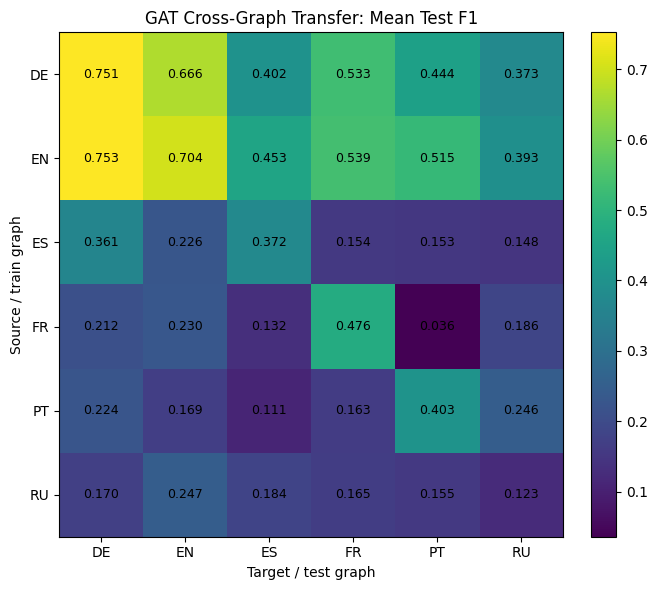

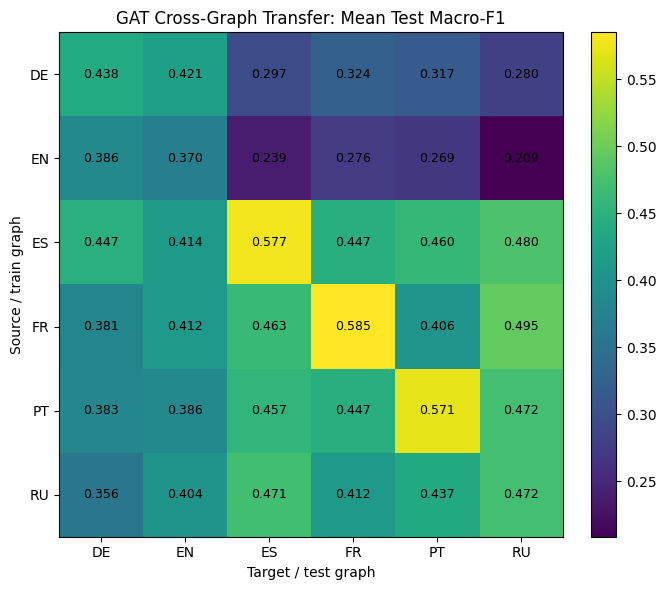

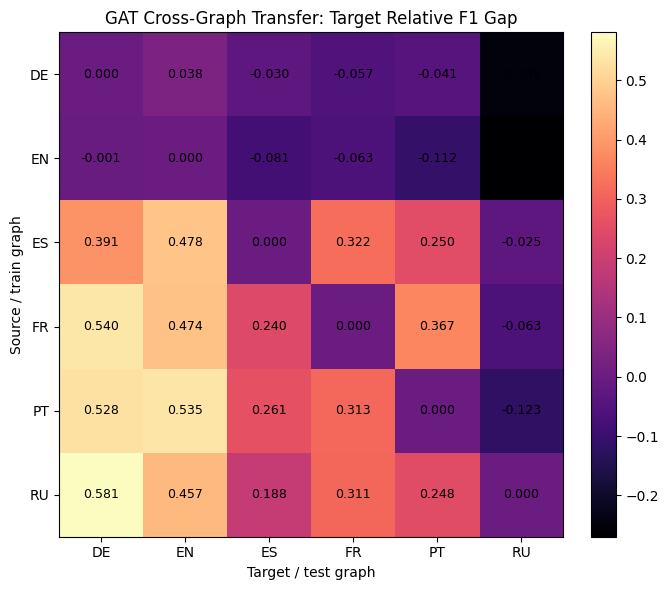

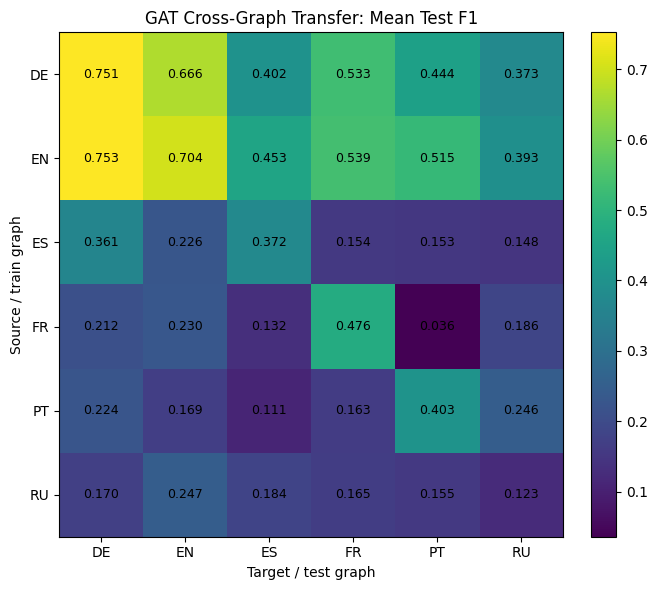

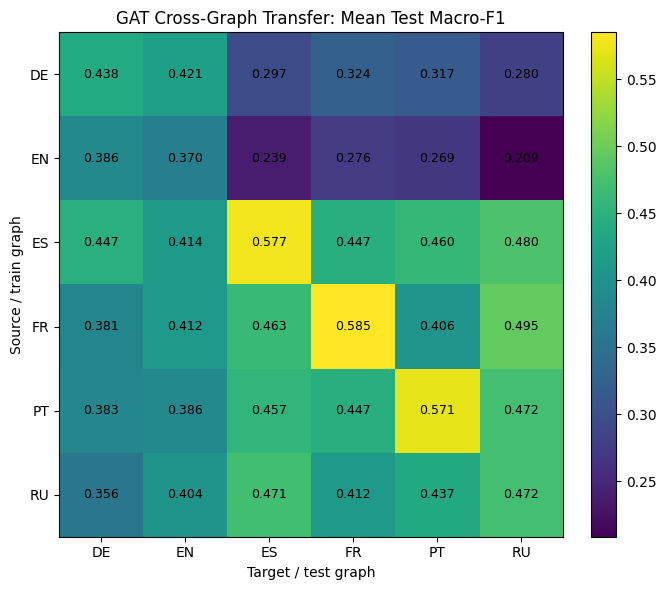

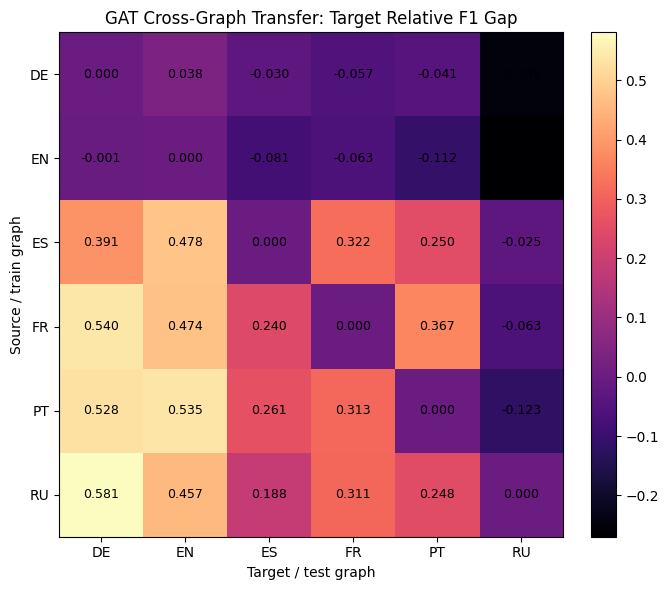

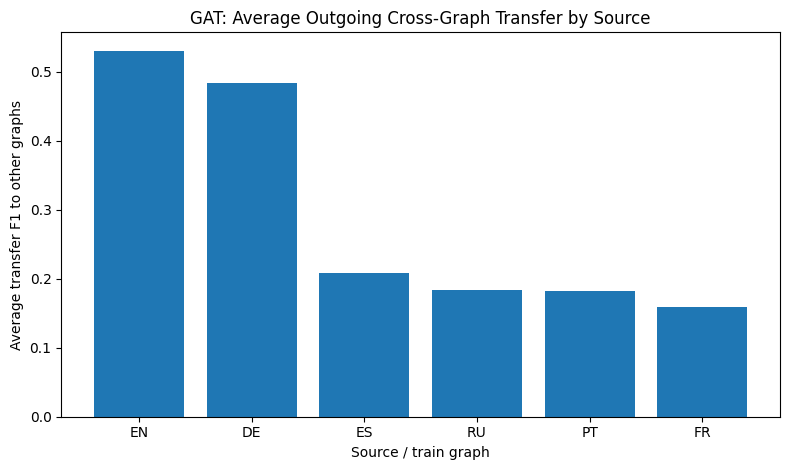

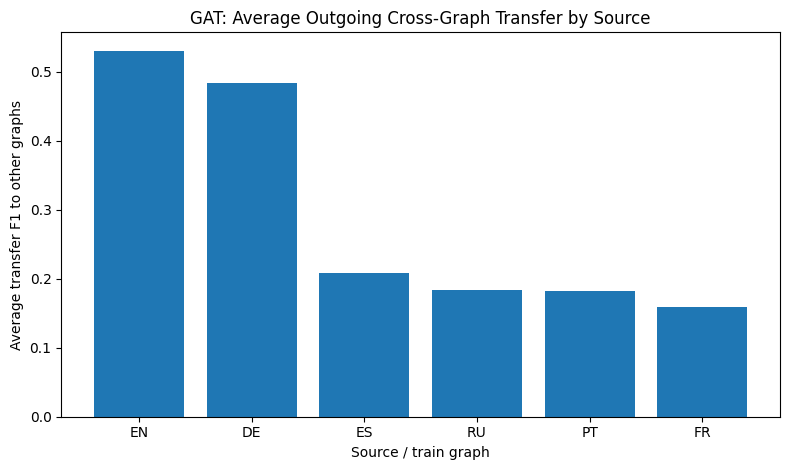

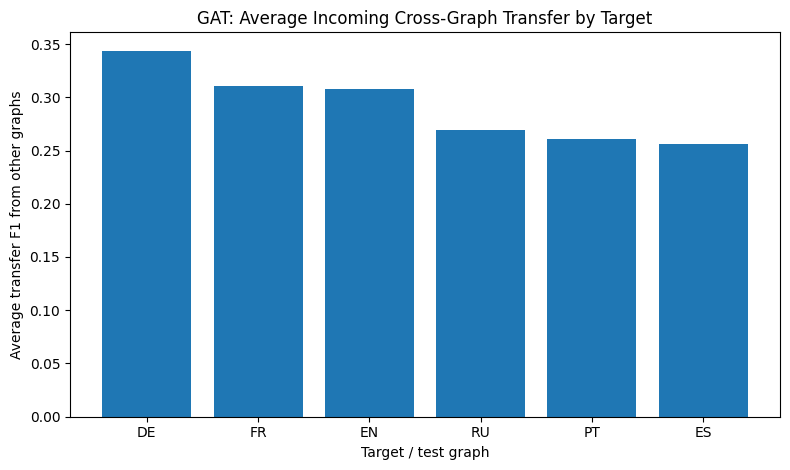

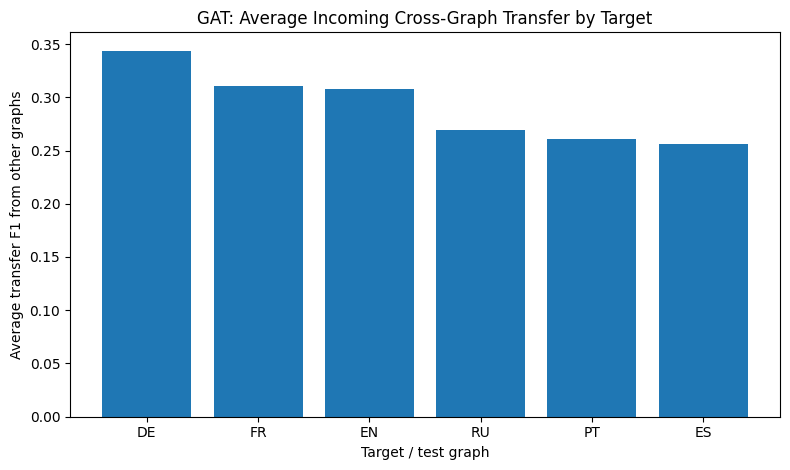

Saved transfer figures to:
   outputs/transfer/figures
   outputs/figures


In [ ]:
# ============================================================
# Cell 10F: Transfer visualizations
# ============================================================

# ------------------------------------------------------------
# 1. Transfer heatmaps
# ------------------------------------------------------------
make_transfer_heatmap(
    matrix_df=transfer_f1_matrix_df,
    title="GAT Cross-Graph Transfer: Mean Test F1",
    save_path=os.path.join(TRANSFER_FIGURES_DIR, "gat_transfer_f1_heatmap.png"),
    fmt=".3f",
    cmap="viridis"
)

make_transfer_heatmap(
    matrix_df=transfer_macro_f1_matrix_df,
    title="GAT Cross-Graph Transfer: Mean Test Macro-F1",
    save_path=os.path.join(TRANSFER_FIGURES_DIR, "gat_transfer_macro_f1_heatmap.png"),
    fmt=".3f",
    cmap="viridis"
)

make_transfer_heatmap(
    matrix_df=target_gap_matrix_df,
    title="GAT Cross-Graph Transfer: Target Relative F1 Gap",
    save_path=os.path.join(TRANSFER_FIGURES_DIR, "gat_transfer_target_gap_heatmap.png"),
    fmt=".3f",
    cmap="magma"
)

# Also save copies in the main figures folder.
make_transfer_heatmap(
    matrix_df=transfer_f1_matrix_df,
    title="GAT Cross-Graph Transfer: Mean Test F1",
    save_path=os.path.join(FIGURES_DIR, "gat_transfer_f1_heatmap.png"),
    fmt=".3f",
    cmap="viridis"
)

make_transfer_heatmap(
    matrix_df=transfer_macro_f1_matrix_df,
    title="GAT Cross-Graph Transfer: Mean Test Macro-F1",
    save_path=os.path.join(FIGURES_DIR, "gat_transfer_macro_f1_heatmap.png"),
    fmt=".3f",
    cmap="viridis"
)

make_transfer_heatmap(
    matrix_df=target_gap_matrix_df,
    title="GAT Cross-Graph Transfer: Target Relative F1 Gap",
    save_path=os.path.join(FIGURES_DIR, "gat_transfer_target_gap_heatmap.png"),
    fmt=".3f",
    cmap="magma"
)

# ------------------------------------------------------------
# 2. Average outgoing transfer by source graph
# ------------------------------------------------------------
source_plot_df = transfer_source_target_summary_df.sort_values(
    "avg_outgoing_transfer_f1",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(8, 4.8))
x = np.arange(len(source_plot_df))
plt.bar(x, source_plot_df["avg_outgoing_transfer_f1"].values)
plt.xticks(x, source_plot_df["dataset"].values)
plt.ylabel("Average transfer F1 to other graphs")
plt.xlabel("Source / train graph")
plt.title("GAT: Average Outgoing Cross-Graph Transfer by Source")
plt.tight_layout()

source_fig_path = os.path.join(
    TRANSFER_FIGURES_DIR,
    "gat_transfer_avg_by_source.png"
)
plt.savefig(source_fig_path, dpi=250)
plt.show()

source_fig_main_path = os.path.join(
    FIGURES_DIR,
    "gat_transfer_avg_by_source.png"
)
plt.figure(figsize=(8, 4.8))
x = np.arange(len(source_plot_df))
plt.bar(x, source_plot_df["avg_outgoing_transfer_f1"].values)
plt.xticks(x, source_plot_df["dataset"].values)
plt.ylabel("Average transfer F1 to other graphs")
plt.xlabel("Source / train graph")
plt.title("GAT: Average Outgoing Cross-Graph Transfer by Source")
plt.tight_layout()
plt.savefig(source_fig_main_path, dpi=250)
plt.show()

# ------------------------------------------------------------
# 3. Average incoming transfer by target graph
# ------------------------------------------------------------
target_plot_df = transfer_source_target_summary_df.sort_values(
    "avg_incoming_transfer_f1",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(8, 4.8))
x = np.arange(len(target_plot_df))
plt.bar(x, target_plot_df["avg_incoming_transfer_f1"].values)
plt.xticks(x, target_plot_df["dataset"].values)
plt.ylabel("Average transfer F1 from other graphs")
plt.xlabel("Target / test graph")
plt.title("GAT: Average Incoming Cross-Graph Transfer by Target")
plt.tight_layout()

target_fig_path = os.path.join(
    TRANSFER_FIGURES_DIR,
    "gat_transfer_avg_by_target.png"
)
plt.savefig(target_fig_path, dpi=250)
plt.show()

target_fig_main_path = os.path.join(
    FIGURES_DIR,
    "gat_transfer_avg_by_target.png"
)
plt.figure(figsize=(8, 4.8))
x = np.arange(len(target_plot_df))
plt.bar(x, target_plot_df["avg_incoming_transfer_f1"].values)
plt.xticks(x, target_plot_df["dataset"].values)
plt.ylabel("Average transfer F1 from other graphs")
plt.xlabel("Target / test graph")
plt.title("GAT: Average Incoming Cross-Graph Transfer by Target")
plt.tight_layout()
plt.savefig(target_fig_main_path, dpi=250)
plt.show()

print("Saved transfer figures to:")
print("  ", TRANSFER_FIGURES_DIR)
print("  ", FIGURES_DIR)

## 10G

,source_dataset,target_dataset,is_within_graph,transfer_f1_mean,target_relative_f1_gap,transfer_macro_f1_mean,target_relative_macro_f1_gap,source_class_1_fraction,target_class_1_fraction,abs_class_1_fraction_diff,...,abs_avg_degree_diff,source_density,target_density,abs_density_diff,source_feature_mean,target_feature_mean,abs_feature_mean_diff,source_feature_std,target_feature_std,abs_feature_std_diff
0,DE,DE,True,0.751423,0.000000,0.438180,0.000000,0.604548,0.604548,0.000000,...,0.000000,0.003395,0.003395,0.000000,0.006415,0.006415,0.000000,0.079833,0.079833,0.000000
1,DE,EN,False,0.666215,0.037795,0.420773,-0.050717,0.604548,0.545608,0.058941,...,11.166125,0.003395,0.001391,0.002004,0.006415,0.006538,0.000123,0.079833,0.080591,0.000758
2,DE,ES,False,0.401764,-0.029835,0.296720,0.280108,0.604548,0.292599,0.311949,...,3.347366,0.003395,0.005499,0.002103,0.006415,0.006095,0.000320,0.079833,0.077829,0.002004
3,DE,FR,False,0.532681,-0.056678,0.323620,0.261463,0.604548,0.368799,0.235750,...,1.075107,0.003395,0.005251,0.001856,0.006415,0.006213,0.000202,0.079833,0.078577,0.001256
4,DE,PT,False,0.444404,-0.041439,0.316537,0.254613,0.604548,0.345711,0.258837,...,0.246586,0.003395,0.017132,0.013737,0.006415,0.006275,0.000140,0.079833,0.078964,0.000869
5,DE,RU,False,0.372596,-0.249486,0.280056,0.192362,0.604548,0.245154,0.359394,...,7.616000,0.003395,0.003881,0.000486,0.006415,0.006495,0.000081,0.079833,0.080330,0.000497
6,EN,DE,False,0.752522,-0.001099,0.385629,0.052551,0.545608,0.604548,0.058941,...,11.166125,0.001391,0.003395,0.002004,0.006538,0.006415,0.000123,0.080591,0.079833,0.000758
7,EN,EN,True,0.704010,0.000000,0.370057,0.000000,0.545608,0.545608,0.000000,...,0.000000,0.001391,0.001391,0.000000,0.006538,0.006538,0.000000,0.080591,0.080591,0.000000
8,EN,ES,False,0.453428,-0.081499,0.239257,0.337571,0.545608,0.292599,0.253009,...,7.818759,0.001391,0.005499,0.004107,0.006538,0.006095,0.000443,0.080591,0.077829,0.002762
9,EN,FR,False,0.539314,-0.063311,0.275646,0.309438,0.545608,0.368799,0.176809,...,12.241232,0.001391,0.005251,0.003860,0.006538,0.006213,0.000325,0.080591,0.078577,0.002014


Saved pairwise transfer diagnostics to: outputs/transfer/metrics/gat_transfer_pairwise_diagnostics.csv
Saved pairwise transfer diagnostics copy to: outputs/metrics/gat_transfer_pairwise_diagnostics.csv


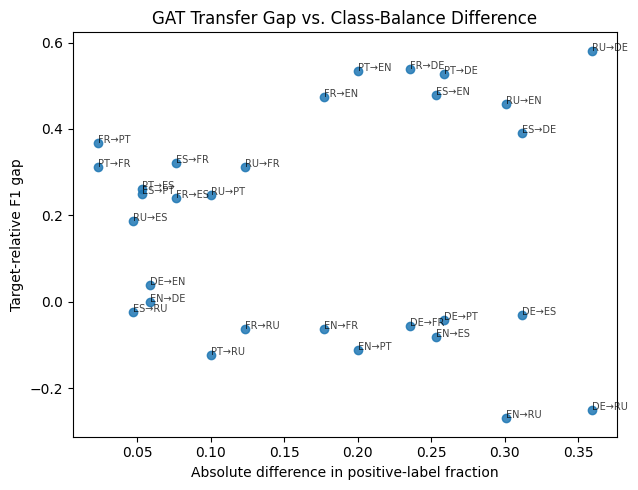

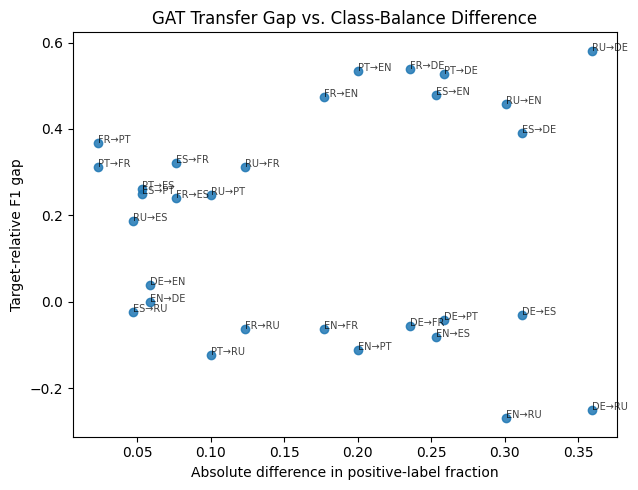

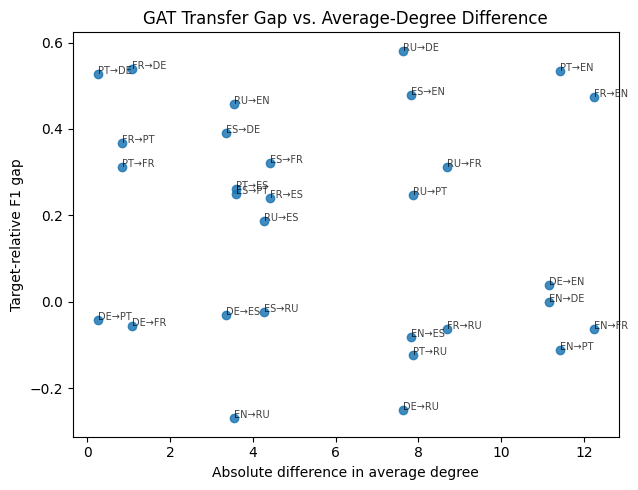

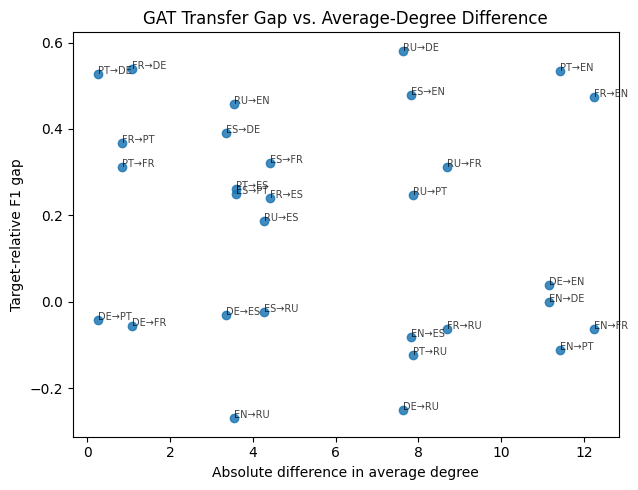

Saved pairwise diagnostic figures.


In [ ]:
# ============================================================
# Cell 10G: Pairwise transfer diagnostics
# ============================================================
# This connects transfer gaps to graph-level differences.
# It is exploratory because there are only six graphs.

summary_lookup = dataset_summary_df.set_index("dataset").to_dict(orient="index")

pairwise_diag_rows = []

for _, row in transfer_with_gaps_df.iterrows():
    source = row["source_dataset"]
    target = row["target_dataset"]

    s = summary_lookup[source]
    t = summary_lookup[target]

    pairwise_diag_rows.append({
        "source_dataset": source,
        "target_dataset": target,
        "is_within_graph": bool(source == target),

        "transfer_f1_mean": float(row["transfer_f1_mean"]),
        "target_relative_f1_gap": float(row["target_relative_f1_gap"]),
        "transfer_macro_f1_mean": float(row["transfer_macro_f1_mean"]),
        "target_relative_macro_f1_gap": float(row["target_relative_macro_f1_gap"]),

        "source_class_1_fraction": float(s["class_1_fraction"]),
        "target_class_1_fraction": float(t["class_1_fraction"]),
        "abs_class_1_fraction_diff": float(abs(s["class_1_fraction"] - t["class_1_fraction"])),

        "source_avg_degree": float(s["avg_degree_directed_count"]),
        "target_avg_degree": float(t["avg_degree_directed_count"]),
        "abs_avg_degree_diff": float(abs(s["avg_degree_directed_count"] - t["avg_degree_directed_count"])),

        "source_density": float(s["density_undirected_approx"]),
        "target_density": float(t["density_undirected_approx"]),
        "abs_density_diff": float(abs(s["density_undirected_approx"] - t["density_undirected_approx"])),

        "source_feature_mean": float(s["feature_mean"]),
        "target_feature_mean": float(t["feature_mean"]),
        "abs_feature_mean_diff": float(abs(s["feature_mean"] - t["feature_mean"])),

        "source_feature_std": float(s["feature_std"]),
        "target_feature_std": float(t["feature_std"]),
        "abs_feature_std_diff": float(abs(s["feature_std"] - t["feature_std"])),
    })

transfer_pairwise_diag_df = pd.DataFrame(pairwise_diag_rows).sort_values(
    ["source_dataset", "target_dataset"]
).reset_index(drop=True)

display(transfer_pairwise_diag_df.head(20))

pairwise_diag_path = os.path.join(
    TRANSFER_METRICS_DIR,
    "gat_transfer_pairwise_diagnostics.csv"
)
transfer_pairwise_diag_df.to_csv(pairwise_diag_path, index=False)

pairwise_diag_main_path = os.path.join(
    METRICS_DIR,
    "gat_transfer_pairwise_diagnostics.csv"
)
transfer_pairwise_diag_df.to_csv(pairwise_diag_main_path, index=False)

print(f"Saved pairwise transfer diagnostics to: {pairwise_diag_path}")
print(f"Saved pairwise transfer diagnostics copy to: {pairwise_diag_main_path}")

# ------------------------------------------------------------
# Scatter plot: target gap vs class-balance difference
# ------------------------------------------------------------
off_diag_pairwise_df = transfer_pairwise_diag_df[
    transfer_pairwise_diag_df["source_dataset"] != transfer_pairwise_diag_df["target_dataset"]
].copy()

plt.figure(figsize=(6.5, 5))
plt.scatter(
    off_diag_pairwise_df["abs_class_1_fraction_diff"],
    off_diag_pairwise_df["target_relative_f1_gap"],
    alpha=0.85
)

for _, r in off_diag_pairwise_df.iterrows():
    label = f"{r['source_dataset']}→{r['target_dataset']}"
    plt.text(
        r["abs_class_1_fraction_diff"],
        r["target_relative_f1_gap"],
        label,
        fontsize=7,
        alpha=0.75
    )

plt.xlabel("Absolute difference in positive-label fraction")
plt.ylabel("Target-relative F1 gap")
plt.title("GAT Transfer Gap vs. Class-Balance Difference")
plt.tight_layout()

fig_path = os.path.join(
    TRANSFER_FIGURES_DIR,
    "gat_transfer_gap_vs_pos_frac_diff.png"
)
plt.savefig(fig_path, dpi=250)
plt.show()

fig_main_path = os.path.join(
    FIGURES_DIR,
    "gat_transfer_gap_vs_pos_frac_diff.png"
)
plt.figure(figsize=(6.5, 5))
plt.scatter(
    off_diag_pairwise_df["abs_class_1_fraction_diff"],
    off_diag_pairwise_df["target_relative_f1_gap"],
    alpha=0.85
)
for _, r in off_diag_pairwise_df.iterrows():
    label = f"{r['source_dataset']}→{r['target_dataset']}"
    plt.text(
        r["abs_class_1_fraction_diff"],
        r["target_relative_f1_gap"],
        label,
        fontsize=7,
        alpha=0.75
    )
plt.xlabel("Absolute difference in positive-label fraction")
plt.ylabel("Target-relative F1 gap")
plt.title("GAT Transfer Gap vs. Class-Balance Difference")
plt.tight_layout()
plt.savefig(fig_main_path, dpi=250)
plt.show()

# ------------------------------------------------------------
# Scatter plot: target gap vs average-degree difference
# ------------------------------------------------------------
plt.figure(figsize=(6.5, 5))
plt.scatter(
    off_diag_pairwise_df["abs_avg_degree_diff"],
    off_diag_pairwise_df["target_relative_f1_gap"],
    alpha=0.85
)

for _, r in off_diag_pairwise_df.iterrows():
    label = f"{r['source_dataset']}→{r['target_dataset']}"
    plt.text(
        r["abs_avg_degree_diff"],
        r["target_relative_f1_gap"],
        label,
        fontsize=7,
        alpha=0.75
    )

plt.xlabel("Absolute difference in average degree")
plt.ylabel("Target-relative F1 gap")
plt.title("GAT Transfer Gap vs. Average-Degree Difference")
plt.tight_layout()

fig_path = os.path.join(
    TRANSFER_FIGURES_DIR,
    "gat_transfer_gap_vs_degree_diff.png"
)
plt.savefig(fig_path, dpi=250)
plt.show()

fig_main_path = os.path.join(
    FIGURES_DIR,
    "gat_transfer_gap_vs_degree_diff.png"
)
plt.figure(figsize=(6.5, 5))
plt.scatter(
    off_diag_pairwise_df["abs_avg_degree_diff"],
    off_diag_pairwise_df["target_relative_f1_gap"],
    alpha=0.85
)
for _, r in off_diag_pairwise_df.iterrows():
    label = f"{r['source_dataset']}→{r['target_dataset']}"
    plt.text(
        r["abs_avg_degree_diff"],
        r["target_relative_f1_gap"],
        label,
        fontsize=7,
        alpha=0.75
    )
plt.xlabel("Absolute difference in average degree")
plt.ylabel("Target-relative F1 gap")
plt.title("GAT Transfer Gap vs. Average-Degree Difference")
plt.tight_layout()
plt.savefig(fig_main_path, dpi=250)
plt.show()

print("Saved pairwise diagnostic figures.")

## 14 - Additional Evaluations

In [ ]:
"""## 14 - Zip transfer outputs"""

# ============================================================
# Cell 14: Zip transfer-only outputs
# ============================================================
import zipfile
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"gat_transfer_outputs_{timestamp}.zip"

paths_to_zip = [
    TRANSFER_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    SPLITS_DIR,
]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root_dir in paths_to_zip:
        if not os.path.exists(root_dir):
            continue

        for foldername, _, filenames in os.walk(root_dir):
            for filename in filenames:
                full_path = os.path.join(foldername, filename)
                arcname = os.path.relpath(full_path, start=".")
                zf.write(full_path, arcname=arcname)

print(f"Created transfer output zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)

Created transfer output zip file: gat_transfer_outputs_20260506_044035.zip
Absolute path: /content/gat_transfer_outputs_20260506_044035.zip

Zip contents:
 - outputs/transfer/metrics/gat_transfer_roc_auc_matrix.csv
 - outputs/transfer/metrics/gat_transfer_macro_f1_matrix.csv
 - outputs/transfer/metrics/gat_transfer_summary.csv
 - outputs/transfer/metrics/gat_transfer_pairwise_diagnostics.csv
 - outputs/transfer/metrics/gat_transfer_with_gaps.csv
 - outputs/transfer/metrics/gat_transfer_accuracy_matrix.csv
 - outputs/transfer/metrics/gat_transfer_target_gap_matrix.csv
 - outputs/transfer/metrics/gat_transfer_source_target_summary.csv
 - outputs/transfer/metrics/gat_transfer_detailed_results.csv
 - outputs/transfer/metrics/gat_transfer_f1_matrix.csv
 - outputs/transfer/figures/gat_transfer_avg_by_source.png
 - outputs/transfer/figures/gat_transfer_macro_f1_heatmap.png
 - outputs/transfer/figures/gat_transfer_target_gap_heatmap.png
 - outputs/transfer/figures/gat_transfer_gap_vs_degree_di

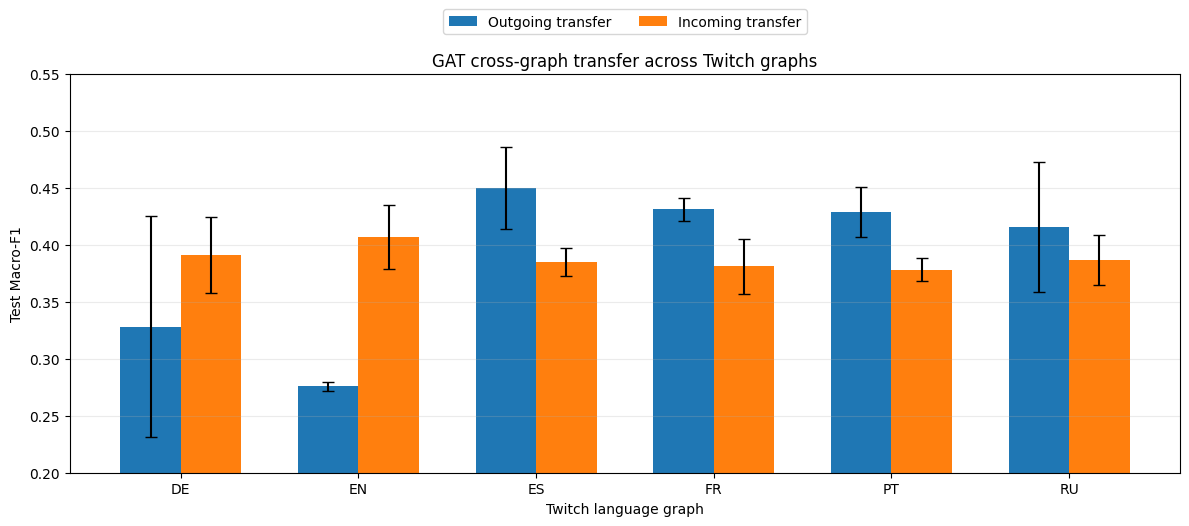

Saved PNG to: figures/gat_transfer_source_target_macro_f1_barplot.png
Saved PDF to: figures/gat_transfer_source_target_macro_f1_barplot.pdf


In [1]:
# ============================================================
# Standalone plot: GAT cross-graph transfer summary
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Hard-coded transfer results
# Mean +/- std across five seeds
# -----------------------------
datasets = ["DE", "EN", "ES", "FR", "PT", "RU"]

outgoing_mean = np.array([0.328, 0.276, 0.450, 0.431, 0.429, 0.416])
outgoing_std  = np.array([0.097, 0.004, 0.036, 0.010, 0.022, 0.057])

incoming_mean = np.array([0.391, 0.407, 0.385, 0.381, 0.378, 0.387])
incoming_std  = np.array([0.033, 0.028, 0.012, 0.024, 0.010, 0.022])

# -----------------------------
# Output folder
# -----------------------------
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(datasets))
width = 0.34

plt.figure(figsize=(12, 5.4))

plt.bar(
    x - width / 2,
    outgoing_mean,
    width,
    yerr=outgoing_std,
    capsize=4,
    label="Outgoing transfer",
)

plt.bar(
    x + width / 2,
    incoming_mean,
    width,
    yerr=incoming_std,
    capsize=4,
    label="Incoming transfer",
)

plt.xticks(x, datasets)
plt.ylabel("Test Macro-F1")
plt.xlabel("Twitch language graph")
plt.title("GAT cross-graph transfer across Twitch graphs")
plt.ylim(0.20, 0.55)
plt.grid(axis="y", alpha=0.25)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=True,
)

plt.tight_layout()

png_path = os.path.join(FIGURES_DIR, "gat_transfer_source_target_macro_f1_barplot.png")
pdf_path = os.path.join(FIGURES_DIR, "gat_transfer_source_target_macro_f1_barplot.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")